In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load your dataset
df = pd.read_excel('crude oil production figshare (1).xlsx')

In [ ]:
# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 10 rows:")
print(df.head(10))
print("\nLast 10 rows:")
print(df.tail(10))
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (177, 5)

First 10 rows:
   Production  Time  Lag1  Lag2  oil price
0        2.25     1  2.47  2.59      61.33
1        2.32     2  2.25  2.47      65.00
2        2.28     3  2.32  2.25      72.09
3        2.41     4  2.28  2.32      71.18
4        2.39     5  2.41  2.28      69.32
5        2.40     6  2.39  2.41      75.13
6        2.40     7  2.40  2.39      75.15
7        2.38     8  2.40  2.40      62.97
8        2.34     9  2.38  2.40      59.49
9        2.36    10  2.34  2.38      59.81

Last 10 rows:
     Production  Time  Lag1  Lag2  oil price
167        2.07   168  2.07  1.96      66.68
168        2.04   169  2.07  2.07      58.45
169        2.04   170  2.04  2.07      32.29
170        1.75   171  2.04  2.04      14.28
171        1.69   172  1.75  2.04      27.90
172        1.69   173  1.69  1.75      40.30
173        1.65   174  1.69  1.69      44.10
174        1.65   175  1.65  1.69      45.06
175        1.54   176  1.65  1.65      40.85
176        1.61   177 

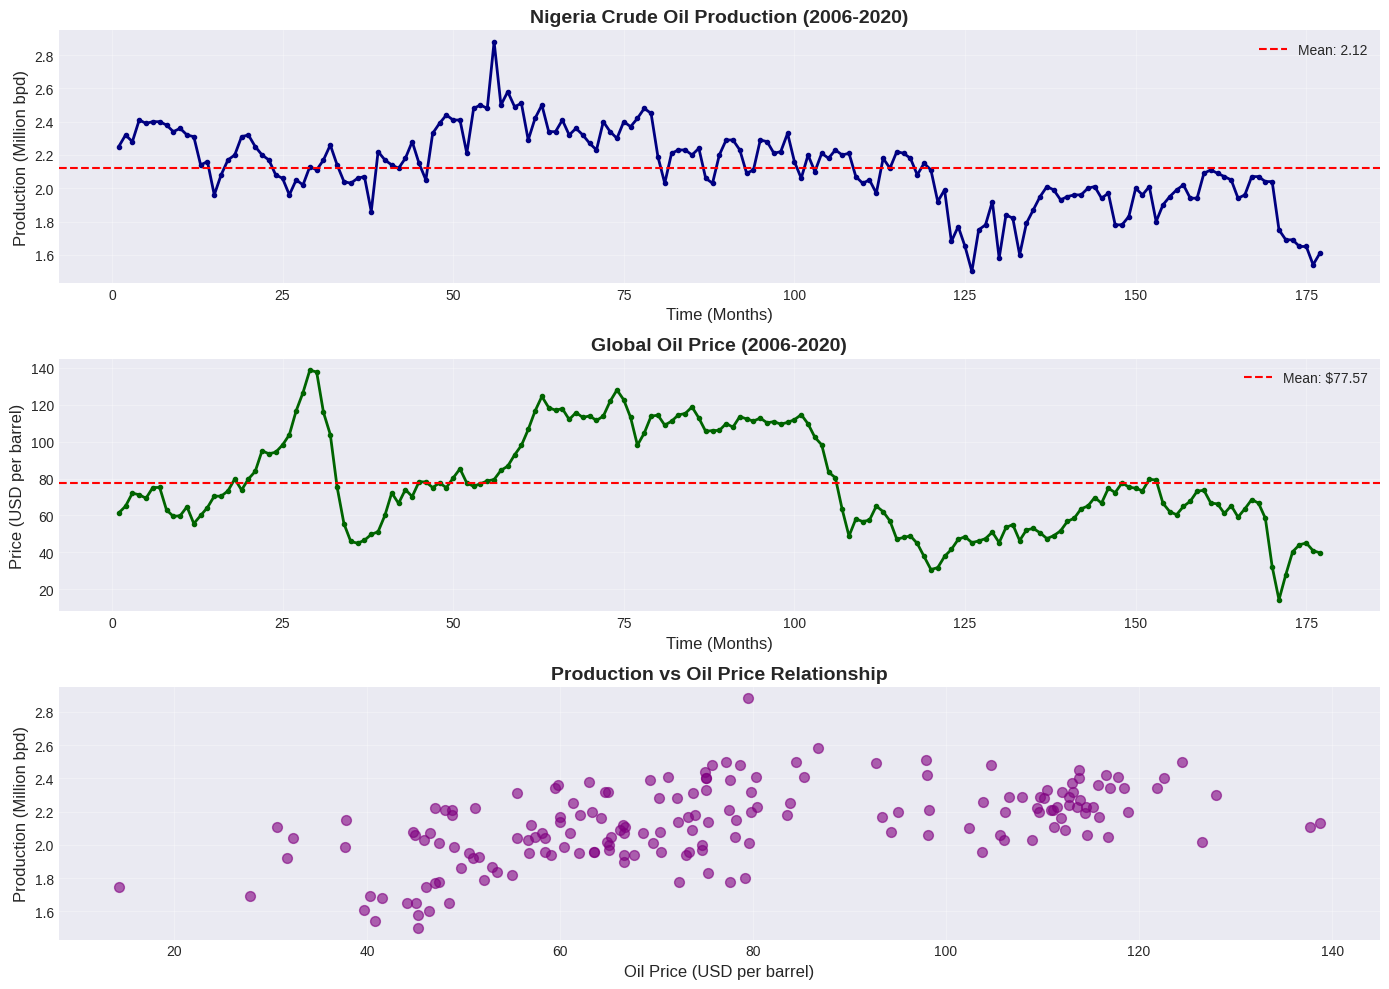


Correlation between Production and Oil Price: 0.5328


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create figure with subplots
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: Production over time
axes[0].plot(df['Time'], df['Production'], linewidth=2, color='navy', marker='o', markersize=3)
axes[0].set_title('Nigeria Crude Oil Production (2006-2020)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time (Months)', fontsize=12)
axes[0].set_ylabel('Production (Million bpd)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=df['Production'].mean(), color='red', linestyle='--', label=f'Mean: {df["Production"].mean():.2f}')
axes[0].legend()

# Plot 2: Oil Price over time
axes[1].plot(df['Time'], df['oil price'], linewidth=2, color='darkgreen', marker='o', markersize=3)
axes[1].set_title('Global Oil Price (2006-2020)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time (Months)', fontsize=12)
axes[1].set_ylabel('Price (USD per barrel)', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=df['oil price'].mean(), color='red', linestyle='--', label=f'Mean: ${df["oil price"].mean():.2f}')
axes[1].legend()

# Plot 3: Production vs Oil Price
axes[2].scatter(df['oil price'], df['Production'], alpha=0.6, s=50, color='purple')
axes[2].set_title('Production vs Oil Price Relationship', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Oil Price (USD per barrel)', fontsize=12)
axes[2].set_ylabel('Production (Million bpd)', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print correlation
print(f"\nCorrelation between Production and Oil Price: {df['Production'].corr(df['oil price']):.4f}")

In [ ]:
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss

# Normality Test
shapiro_stat, shapiro_p = stats.shapiro(df['Production'])
print("="*50)
print("NORMALITY TEST (Shapiro-Wilk)")
print("="*50)
print(f"Statistic: {shapiro_stat:.4f}")
print(f"P-value: {shapiro_p:.4f}")
print(f"Result: {'Normal' if shapiro_p > 0.05 else 'Not Normal'} distribution")

# Stationarity Test - ADF
print("\n" + "="*50)
print("STATIONARITY TEST (Augmented Dickey-Fuller)")
print("="*50)
adf_result = adfuller(df['Production'])
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"P-value: {adf_result[1]:.4f}")
print(f"Critical Values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value:.4f}")
print(f"Result: {'Stationary' if adf_result[1] < 0.05 else 'Non-Stationary'}")

# KPSS Test
print("\n" + "="*50)
print("STATIONARITY TEST (KPSS)")
print("="*50)
kpss_result = kpss(df['Production'], regression='c')
print(f"KPSS Statistic: {kpss_result[0]:.4f}")
print(f"P-value: {kpss_result[1]:.4f}")
print(f"Critical Values:")
for key, value in kpss_result[3].items():
    print(f"  {key}: {value:.4f}")
print(f"Result: {'Stationary' if kpss_result[1] > 0.05 else 'Non-Stationary'}")

NORMALITY TEST (Shapiro-Wilk)
Statistic: 0.9849
P-value: 0.0529
Result: Normal distribution

STATIONARITY TEST (Augmented Dickey-Fuller)
ADF Statistic: -2.1321
P-value: 0.2318
Critical Values:
  1%: -3.4683
  5%: -2.8782
  10%: -2.5757
Result: Non-Stationary

STATIONARITY TEST (KPSS)
KPSS Statistic: 1.1723
P-value: 0.0100
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390
Result: Non-Stationary


/tmp/ipython-input-1194232222.py:29: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(df['Production'], regression='c')


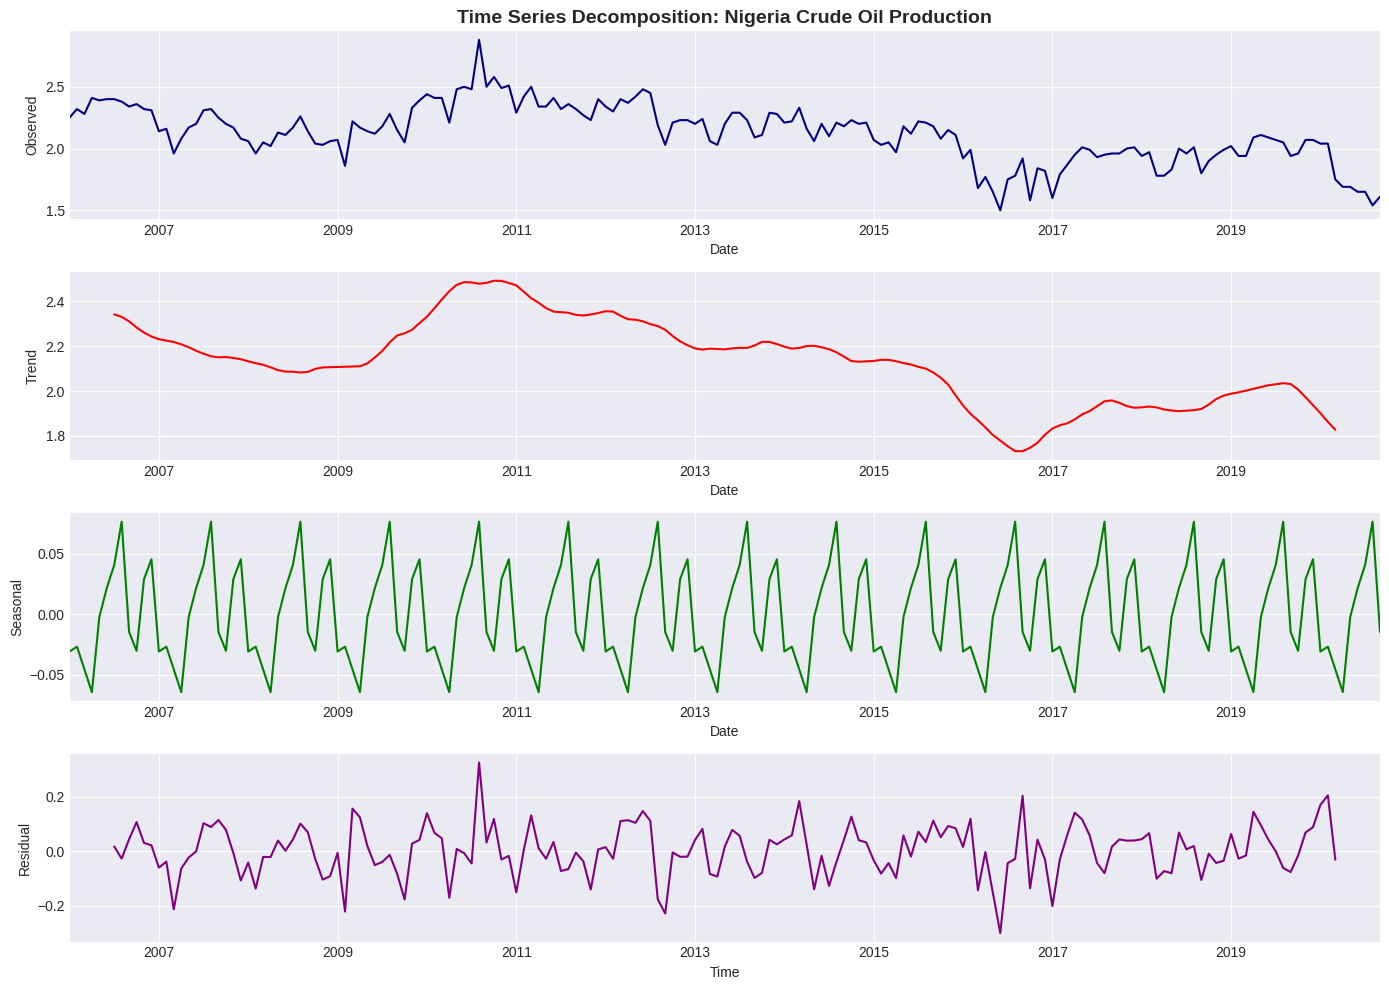


DECOMPOSITION STATISTICS
Trend Component - Mean: 2.1318
Seasonal Component - Range: -0.0642 to 0.0766
Residual Component - Std Dev: 0.0930
Seasonal Strength: 0.1619


In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Create a proper datetime index for decomposition
df['Date'] = pd.date_range(start='2006-01', periods=len(df), freq='MS')
df_decompose = df.set_index('Date')

# Perform seasonal decomposition
decomposition = seasonal_decompose(df_decompose['Production'], model='additive', period=12)

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

decomposition.observed.plot(ax=axes[0], color='navy')
axes[0].set_ylabel('Observed')
axes[0].set_title('Time Series Decomposition: Nigeria Crude Oil Production', fontsize=14, fontweight='bold')

decomposition.trend.plot(ax=axes[1], color='red')
axes[1].set_ylabel('Trend')

decomposition.seasonal.plot(ax=axes[2], color='green')
axes[2].set_ylabel('Seasonal')

decomposition.resid.plot(ax=axes[3], color='purple')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Time')

plt.tight_layout()
plt.show()

# Print decomposition statistics
print("\nDECOMPOSITION STATISTICS")
print("="*50)
print(f"Trend Component - Mean: {decomposition.trend.mean():.4f}")
print(f"Seasonal Component - Range: {decomposition.seasonal.min():.4f} to {decomposition.seasonal.max():.4f}")
print(f"Residual Component - Std Dev: {decomposition.resid.std():.4f}")
print(f"Seasonal Strength: {(1 - (decomposition.resid.var() / (decomposition.seasonal + decomposition.resid).var())):.4f}")